In [742]:
import pandas as pd
import numpy as np
from numpy import random
import matplotlib.pyplot as plt

import seaborn as sns

sns.set_style("whitegrid")



In [743]:
file_path="/Users/tejasmac/Data Analytics Portfolio/Datasets/zomato.csv"
df=pd.read_csv(file_path)


In [744]:
# a copy of our original dataset which we will use for EDA
df_cleaned=df.copy()

In [ ]:
#gives top 5 rows of our original dataset
print(df.head())

In [ ]:
#gives info of the dataset with respective data type
print(df.info())

In [ ]:
#gives a list of columns of the dataset
print(df.columns)


In [ ]:
#to check number of rows and columns in the dataset
print(df.shape)

In [749]:
# Rating CLEANING 


df_cleaned["rate"]=df_cleaned["rate"].str.replace("/5","")
df_cleaned["rate"]=df_cleaned["rate"].replace("-",np.nan)
df_cleaned["rate"]=df_cleaned["rate"].replace("NEW",np.nan)
df_cleaned["rate"]=df_cleaned["rate"].str.strip()
df_cleaned["rate"]=df_cleaned["rate"].replace("",np.nan)

df_cleaned["rate"]=pd.to_numeric(df_cleaned["rate"])


df_cleaned=df_cleaned.dropna(subset=["rate"])



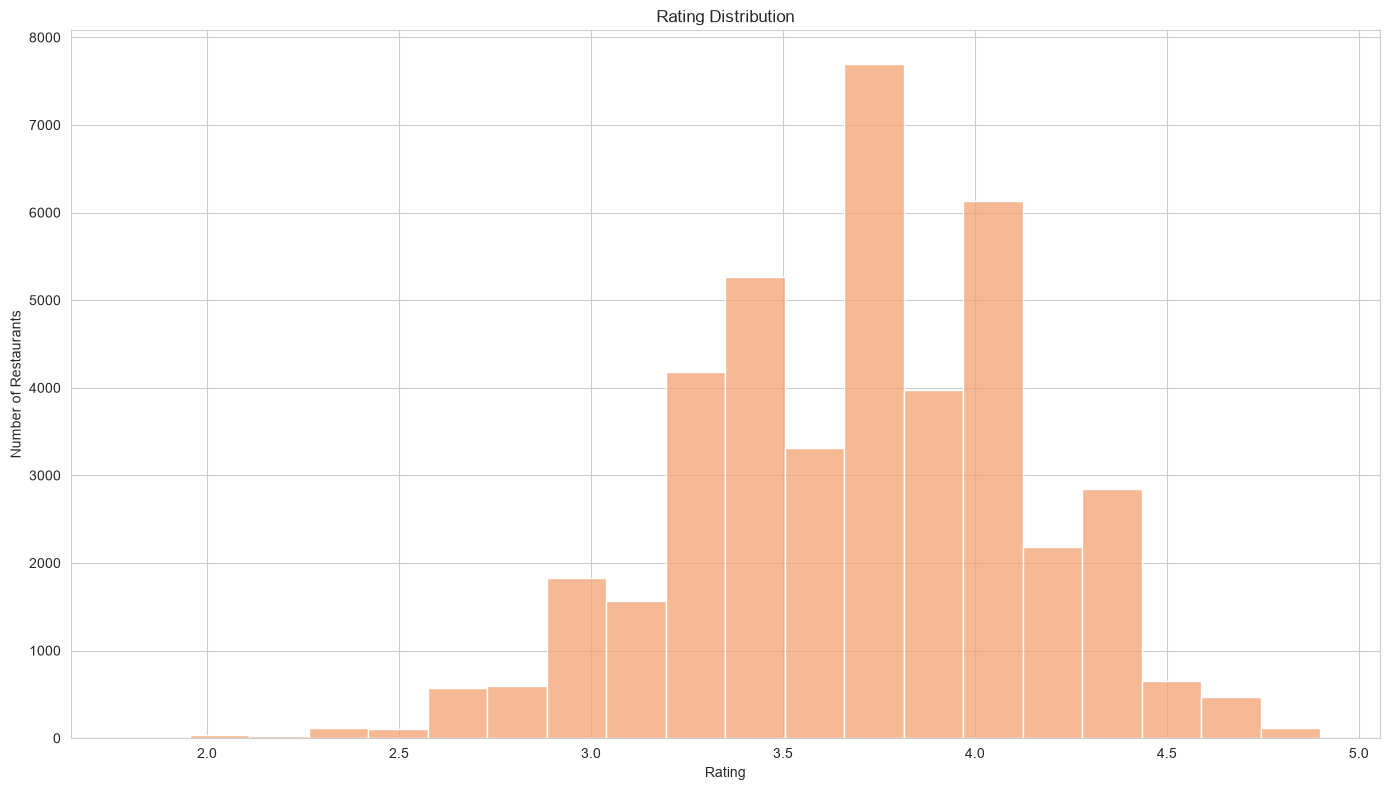

In [750]:
#Rating Disttribution Graph

plt.figure(figsize=(14,8))

sns.histplot(data=df_cleaned["rate"],bins=20,color="#f2a270")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")
plt.title("Rating Distribution")


plt.tight_layout()

### Key Insights

**Observation**

* Most restaurants have ratings between **3.3 and 4.2**, indicating that the majority of restaurants are rated above average.

**Insight**

* Highly rated restaurants are far more common than poorly rated ones, suggesting that most listed restaurants maintain a satisfactory level of customer experience.

**Business Recommendation**

* Restaurants should aim to maintain a rating of **3.5 or higher** by consistently improving food quality, service, and customer experience, as higher ratings are likely to improve customer trust and visibility.


In [751]:
# rest_type CLEANING 

df_rest_type=df_cleaned.copy()

df_rest_type["rest_type"]=df_rest_type["rest_type"].str.split(", ")
df_rest_type=df_rest_type.explode(["rest_type"])

df_rest_type=df_rest_type.dropna(subset=["rest_type"])

df_rest_type["rest_type"]=df_rest_type["rest_type"].str.strip()





In [752]:
# dish_liked CLEANING
df_dish=df_cleaned.copy()

df_dish=df_dish.dropna(subset=["dish_liked"])
df_dish["dish_liked"]=df_dish["dish_liked"].str.split(", ")
df_dish=df_dish.explode("dish_liked")


In [753]:
# cuisines CLEANING

df_cuisines=df_cleaned.copy()

df_cuisines=df_cuisines.dropna(subset=["cuisines"])

df_cuisines["cuisines"]=df_cuisines["cuisines"].str.split(", ")
df_cuisines=df_cuisines.explode("cuisines")




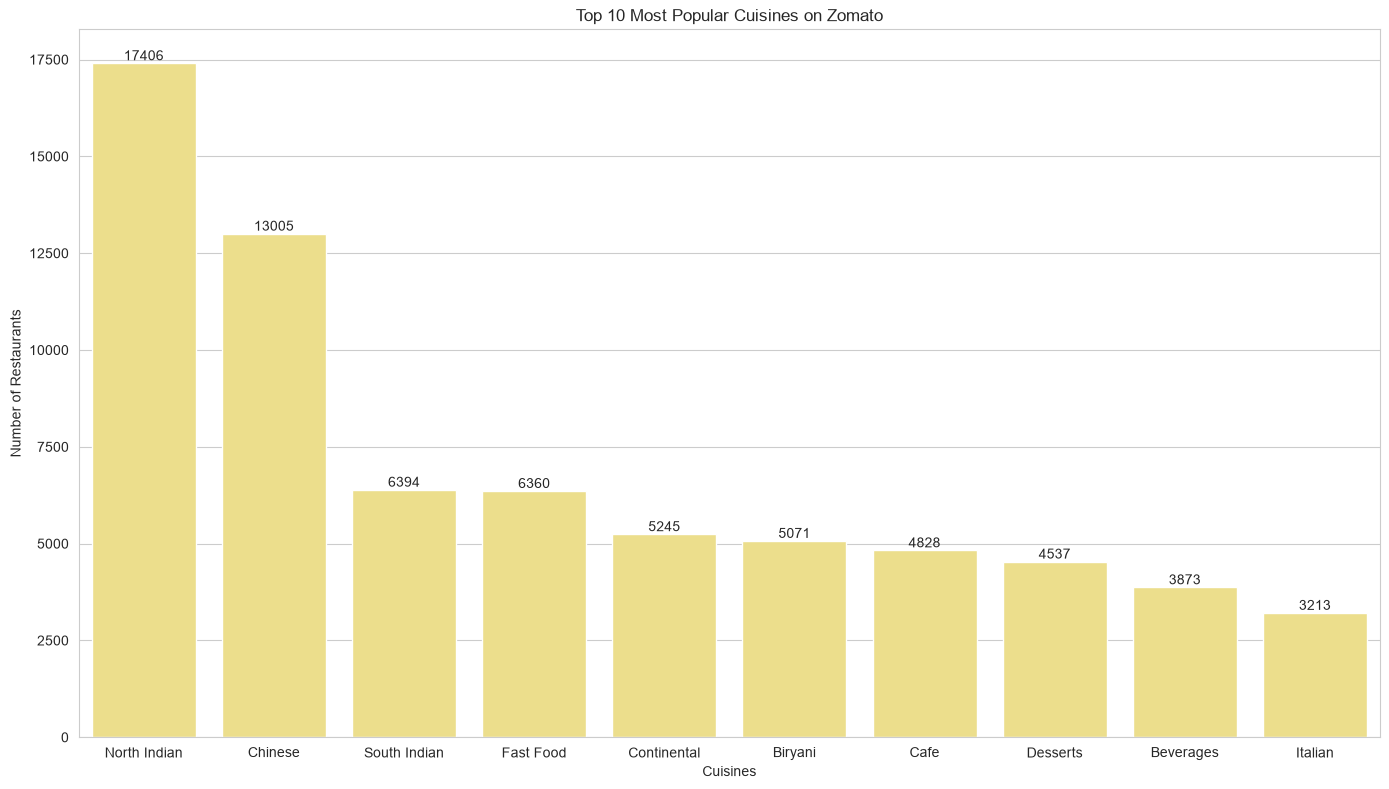

In [754]:
#Top 10 Cuisines Graph

comparison_cuisines=df_cuisines.groupby("cuisines")["name"].size().reset_index(name="count").sort_values(by="count",ascending=False).head(10)

plt.figure(figsize=(14,8))
ax=sns.barplot(x="cuisines",y="count",data=comparison_cuisines,color="#FCE97C")

for i in ax.containers:
   ax.bar_label(i)


plt.xlabel("Cuisines")
plt.ylabel("Number of Restaurants")
plt.title("Top 10 Most Popular Cuisines on Zomato")


plt.tight_layout()

### Key Insights

**Observation**

* **North Indian** cuisine has the highest number of restaurants, followed by **Chinese**. In comparison, **Beverages** and **Italian** cuisines have relatively fewer restaurants among the top 10.

**Insight**

* Cuisines such as **South Indian**, **Continental**, and **Biryani** have a similar number of restaurants, indicating balanced representation in the market.

**Business Recommendation**

* Entrepreneurs planning to open a new restaurant may find **Italian**, **Beverages**, or **Desserts** to be relatively less competitive than **North Indian** or **Chinese** cuisine. However, before making a business decision, demand, customer preferences, and profitability should also be evaluated—not just the number of existing restaurants.


In [755]:
# approx_cost(for two people) CLEANING

df_cleaned["approx_cost(for two people)"]=df_cleaned["approx_cost(for two people)"].str.strip()
df_cleaned["approx_cost(for two people)"]=df_cleaned["approx_cost(for two people)"].str.replace(",","")

df_cleaned["approx_cost(for two people)"]=pd.to_numeric(df_cleaned["approx_cost(for two people)"])

df_cleaned=df_cleaned.dropna(subset=["approx_cost(for two people)"])

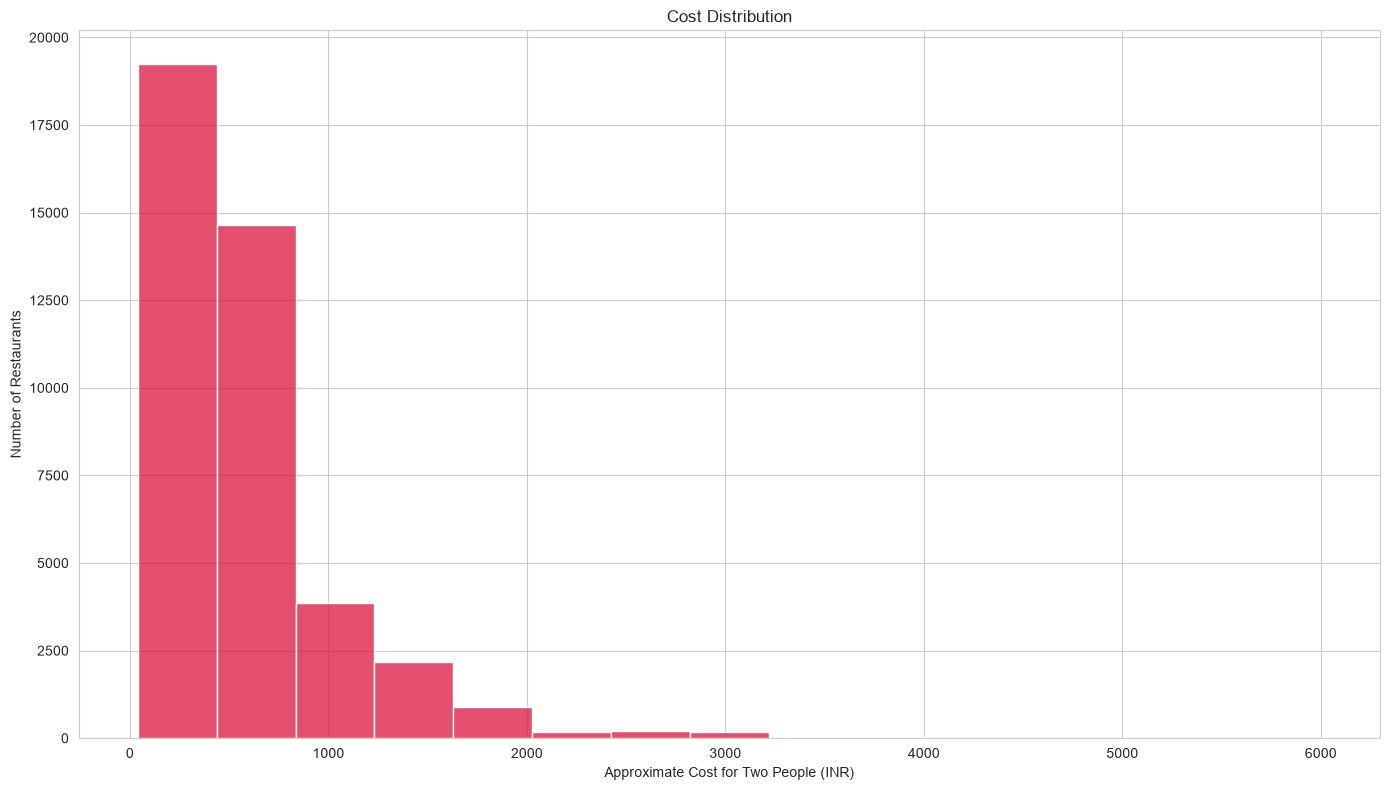

In [756]:
#Cost Distribution

plt.figure(figsize=(14,8))
sns.histplot(data=df_cleaned["approx_cost(for two people)"],bins=15,color="crimson")

plt.xlabel("Approximate Cost for Two People (INR)")
plt.ylabel("Number of Restaurants")
plt.title("Cost Distribution")

plt.tight_layout()

### Key Insights

**Observation**

* Most restaurants are concentrated in the **mid-price range**, while very low-cost and very high-cost restaurants are comparatively fewer in number.

**Insight**

* The restaurant market in Bangalore appears to be dominated by moderately priced restaurants, indicating that customers have a greater preference for mid-range dining options.

**Business Recommendation**

* Restaurant owners should consider pricing their offerings competitively within the mid-range segment to attract a larger customer base. However, businesses targeting budget or premium customers can still differentiate themselves by offering unique value and customer experience.



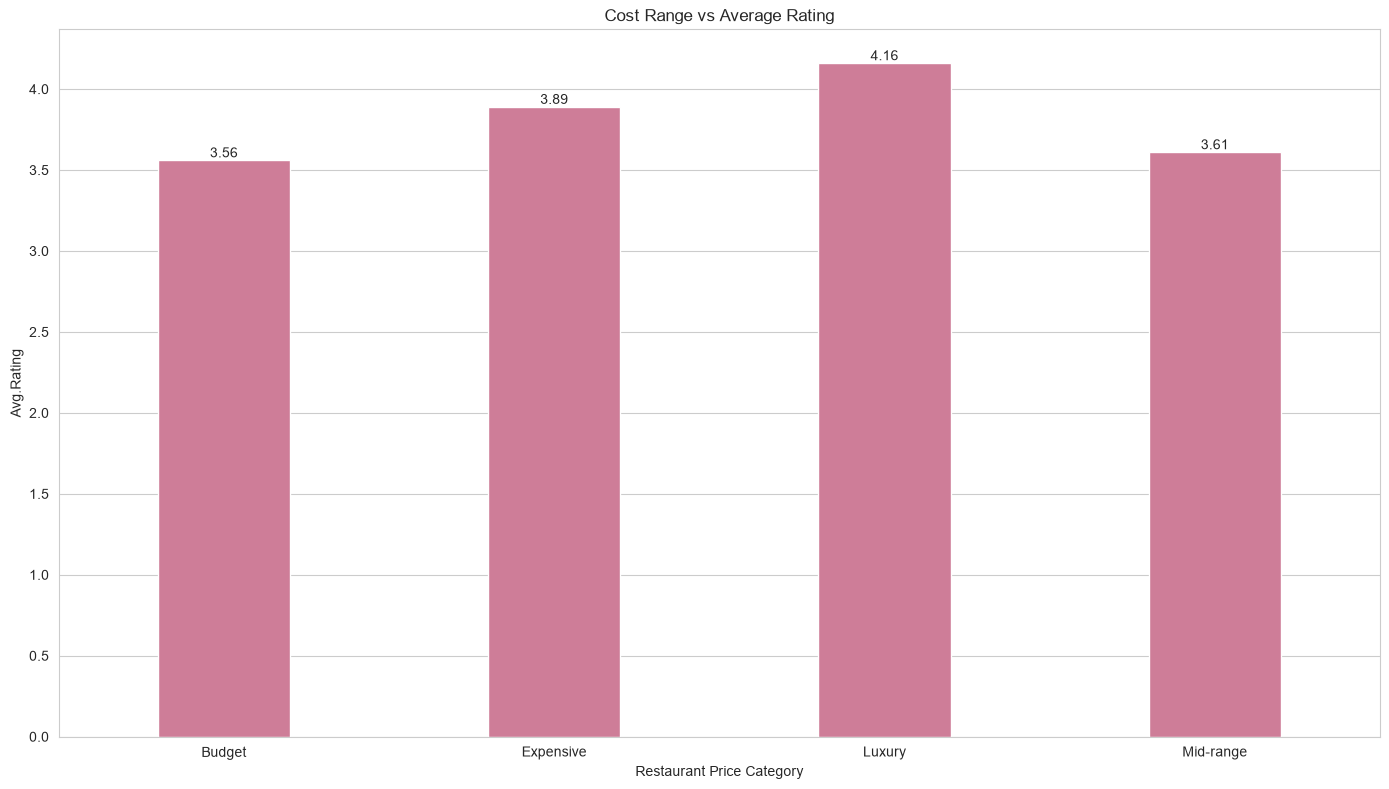

In [757]:
#Cost vs Rating

df_cost_rating=df_cleaned.copy()

df_cost_rating["cost_range"]=df_cost_rating["approx_cost(for two people)"].apply(lambda x: 
                                                                                                "Budget" if x<300
                                                                                                 else "Mid-range" if x<700
                                                                                                 else "Expensive" if x<1500
                                                                                                 else "Luxury")


comparison=df_cost_rating.groupby("cost_range")["rate"].mean().round(2).reset_index(name="count")


plt.figure(figsize=(14,8))
ax=sns.barplot(x="cost_range",y="count",data=comparison,width=.4,color="palevioletred")

for i in ax.containers:
    ax.bar_label(i)

plt.xlabel("Restaurant Price Category")
plt.ylabel("Avg.Rating")
plt.title("Cost Range vs Average Rating")

plt.tight_layout()



### Key Insights

**Observation**

* Luxury category restaurants have the highest average ratings, while Budget and Mid-range restaurants have comparatively lower average ratings. Expensive restaurants fall between these categories.

**Insight**

* There appears to be a positive association between restaurant price category and average customer rating. Higher priced restaurants tend to receive better ratings, possibly because of differences in food quality, ambience, or service.

**Business Recommendation**

* Rather than increasing prices, restaurants should focus on improving the factors that influence customer satisfaction such as food quality, service, and ambience—to achieve higher ratings while remaining competitive within their target price segment.


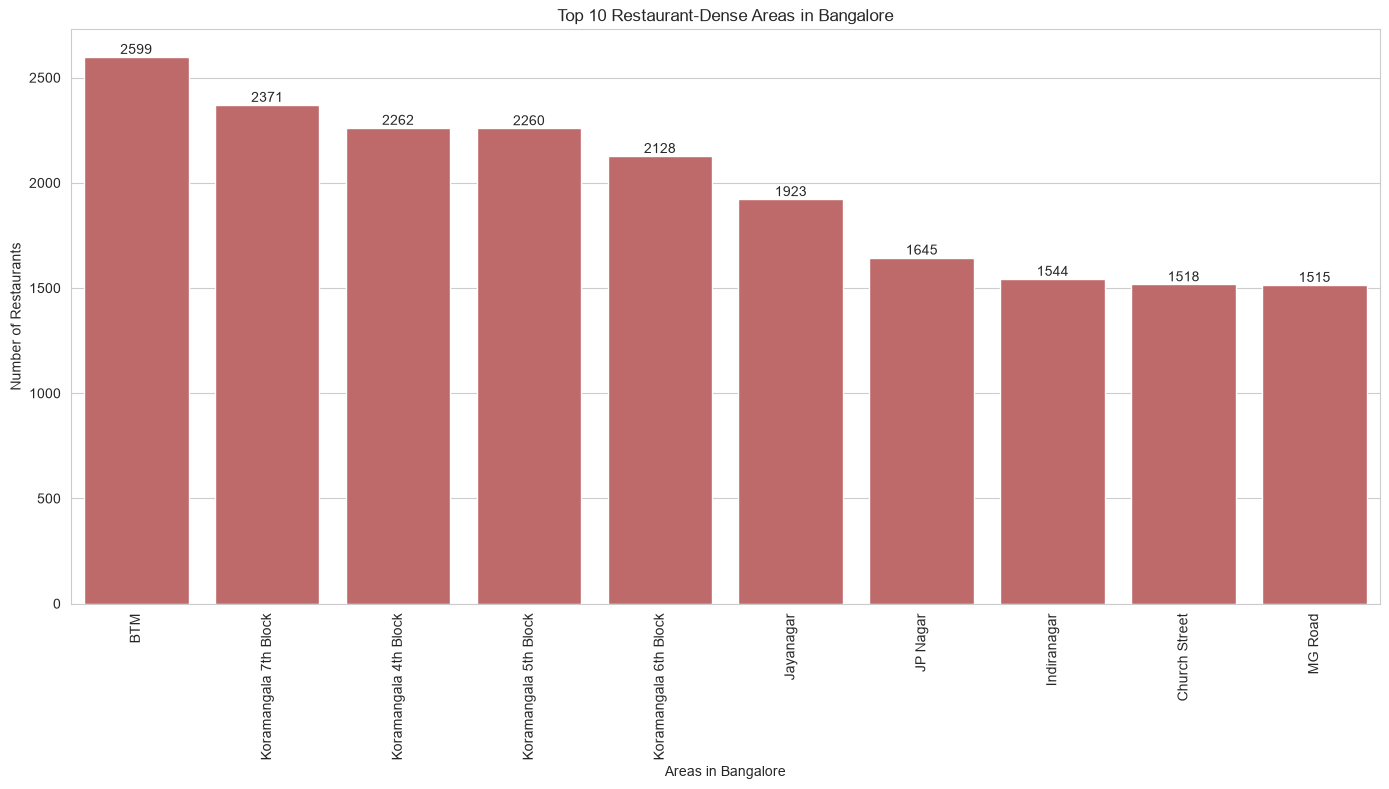

In [758]:
#Location Analysis Graph

comparison_location=df_cleaned.groupby("listed_in(city)")["name"].size().reset_index(name="count").sort_values(by="count",ascending=False).head(10)

plt.figure(figsize=(14,8))
ax=sns.barplot(x="listed_in(city)",y="count",data=comparison_location,color="indianred")

for i in ax.containers:
    ax.bar_label(i)


plt.xlabel("Areas in Bangalore")
plt.ylabel("Number of Restaurants")
plt.title("Top 10 Restaurant-Dense Areas in Bangalore")

plt.xticks(rotation=90)
plt.tight_layout()

### Key Insights

**Observation**

* **BTM** and **Koramangala 7th Block** have the highest concentration of restaurants, followed by areas such as **Indiranagar**, **Church Street**, and **MG Road**.

**Insight**

* Areas like **Koramangala 4th Block**, **Koramangala 5th Block**, and **Koramangala 6th Block** have a similar and moderate number of restaurants, indicating a relatively balanced restaurant presence across these localities.

**Business Recommendation**

* While BTM and Koramangala 7th Block have intense competition due to the high number of restaurants, locations such as **Indiranagar**, **Church Street**, and **MG Road** may still offer business opportunities. However, before opening a new restaurant, factors such as customer demand, target audience, cuisine preferences, rental costs, and local competition should be carefully evaluated.


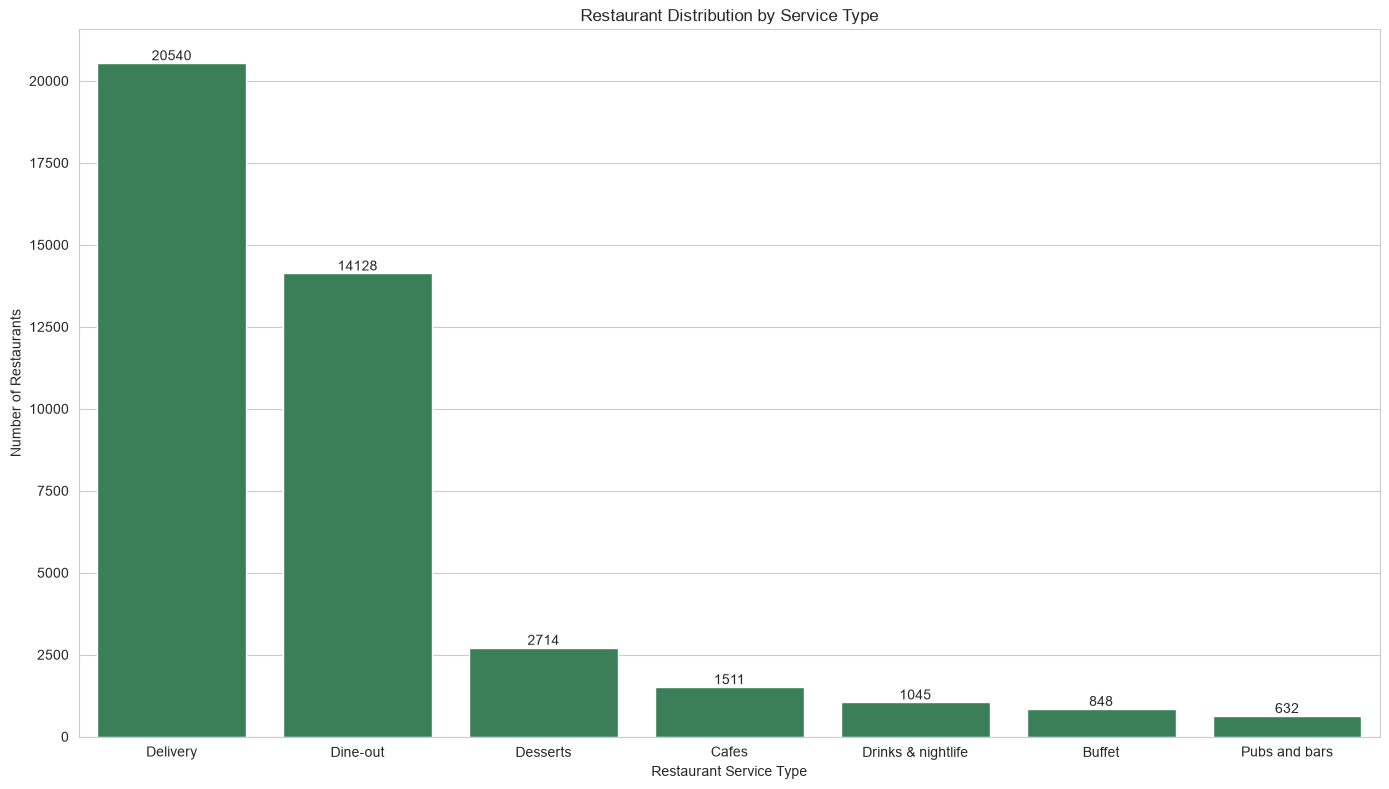

In [759]:
#Restaurant Type Analysis


comparison_type=df_cleaned.groupby("listed_in(type)")["name"].size().reset_index(name="count").sort_values(by="count",ascending=False)



plt.figure(figsize=(14,8))
ax=sns.barplot(x="listed_in(type)",y="count",data=comparison_type,color="seagreen")

for i in ax.containers:
    ax.bar_label(i)

plt.xlabel("Restaurant Service Type")
plt.ylabel("Number of Restaurants")
plt.title("Restaurant Distribution by Service Type")
plt.tight_layout()


### Key Insights

**Observation**

* Delivery and Dine-out restaurants dominate the platform, while Pubs and Bars and Buffets have comparatively fewer restaurants.

**Insight**

* Restaurants primarily focus on everyday dining and food delivery services, reflecting customer demand for convenience and frequent dining.

**Business Recommendation**

* Restaurant owners should prioritize delivery-friendly operations and efficient dine-out experiences. Businesses planning buffet or pub-based models should carefully assess location, customer demand, and competition before entering the market.



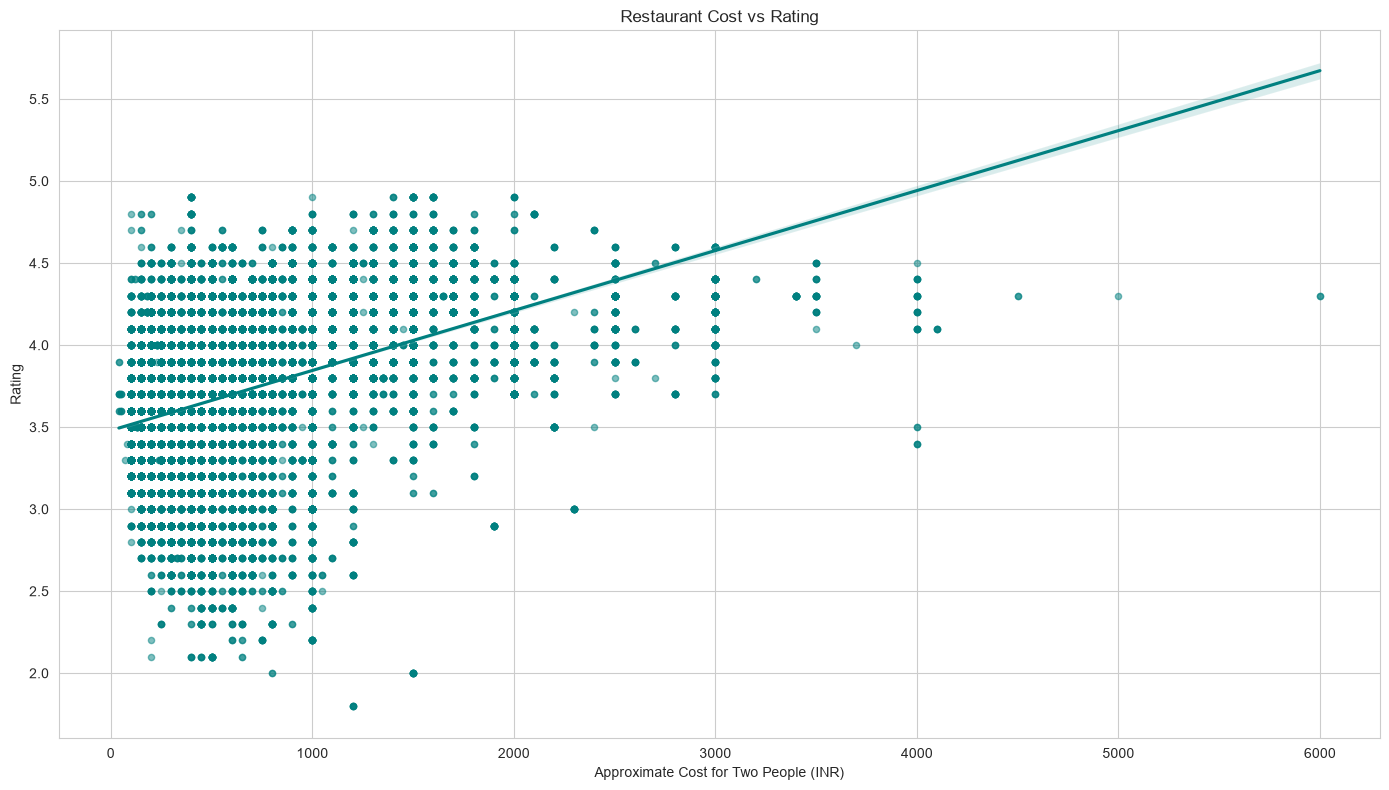

In [760]:
# Relation b/w expesnive restaurants and ratings

plt.figure(figsize=(14,8))
sns.regplot(x="approx_cost(for two people)",y="rate",data=df_cleaned,color="teal",scatter_kws={"alpha":0.5,"s":20})

plt.xlabel("Approximate Cost for Two People (INR)")
plt.ylabel("Rating")
plt.title("Restaurant Cost vs Rating")


plt.tight_layout()

### Key Insights

**Observation**

* Restaurant ratings show a slight upward trend with increasing cost, although considerable variation exists across all price ranges.

**Insight**

* Higher-priced restaurants generally tend to receive better ratings, but price alone does not determine customer satisfaction.

**Business Recommendation**

* Restaurants should focus on improving food quality, service, and ambience rather than increasing prices, as customer experience plays a greater role in achieving higher ratings.


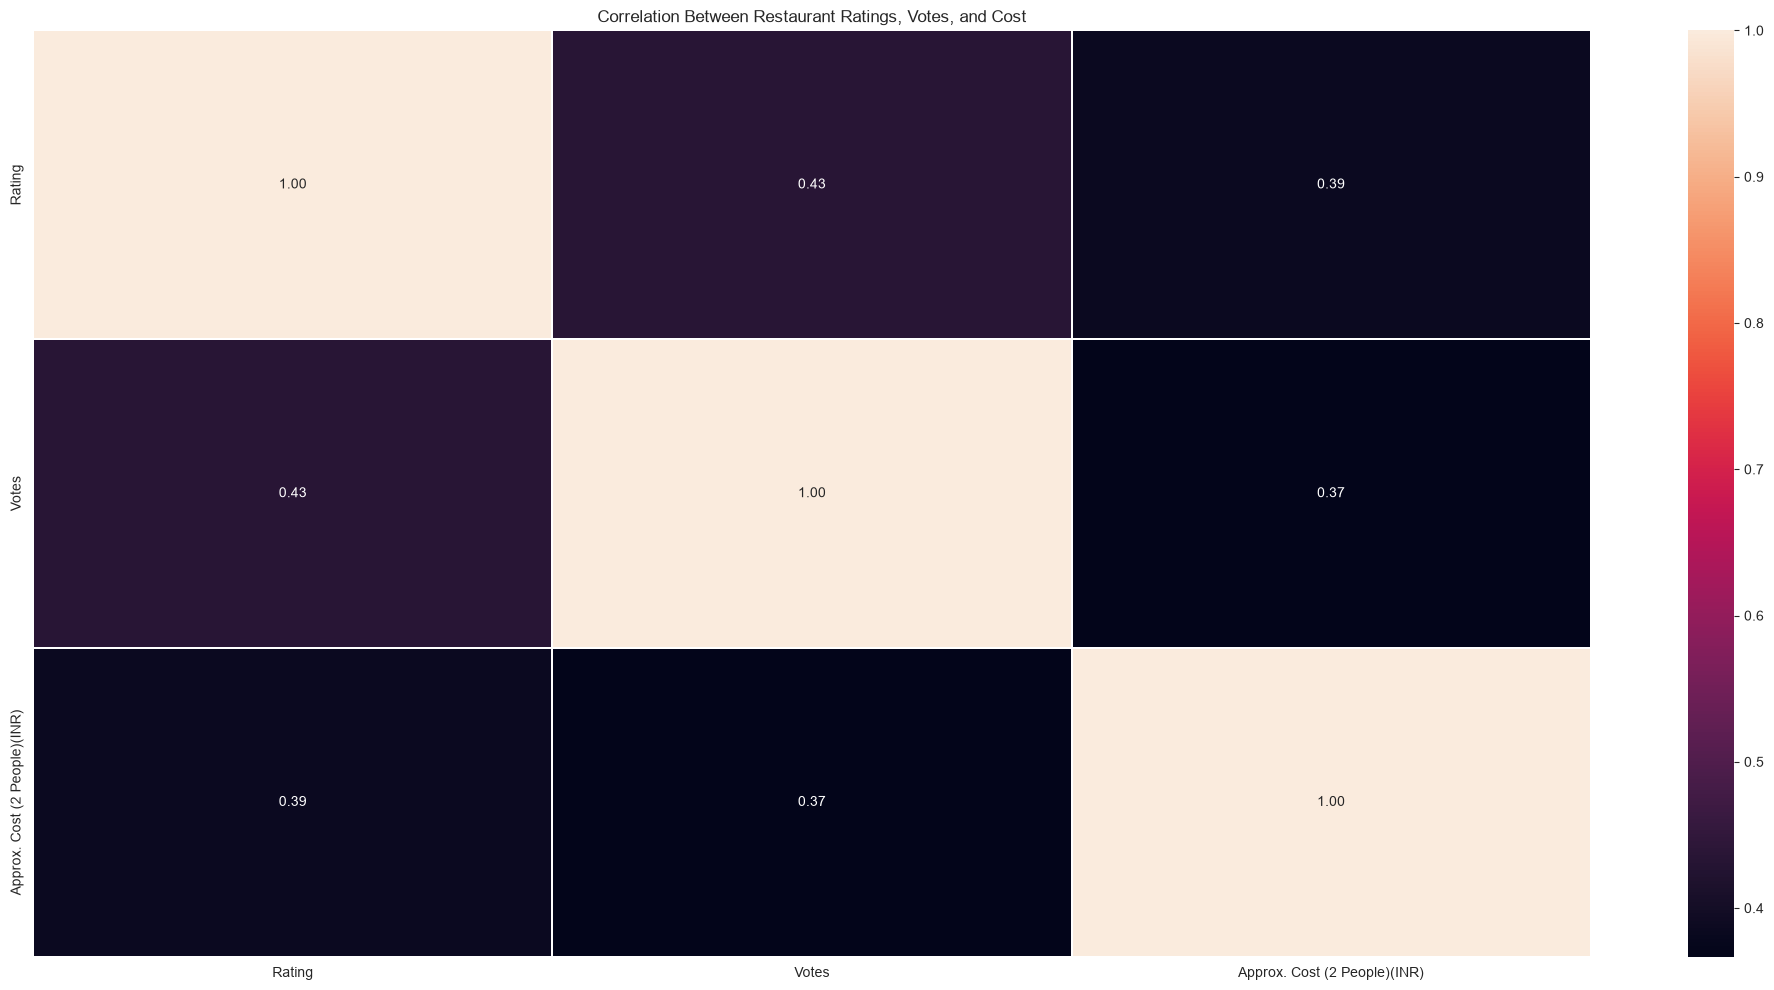

In [761]:
#Heatmap

plt.figure(figsize=(20,10))
ax=sns.heatmap(df_cleaned[["rate","votes","approx_cost(for two people)"]].corr(),annot=True,cmap="rocket",fmt=".2f",linewidths=0.3)

ax.set_xticklabels(["Rating", "Votes", "Approx. Cost (2 People)(INR)"])
ax.set_yticklabels(["Rating", "Votes", "Approx. Cost (2 People)(INR)"])
plt.title("Correlation Between Restaurant Ratings, Votes, and Cost")
plt.tight_layout()

### Key Insights

**Observation**

* Ratings show a weak positive correlation with restaurant cost, while votes exhibit a stronger positive relationship with ratings.

**Insight**

* Highly rated restaurants generally receive more customer engagement in the form of votes, indicating greater popularity and visibility.

**Business Recommendation**

* Restaurants should encourage customer reviews and consistently maintain service quality to improve ratings, which may increase customer engagement and visibility on the platform.


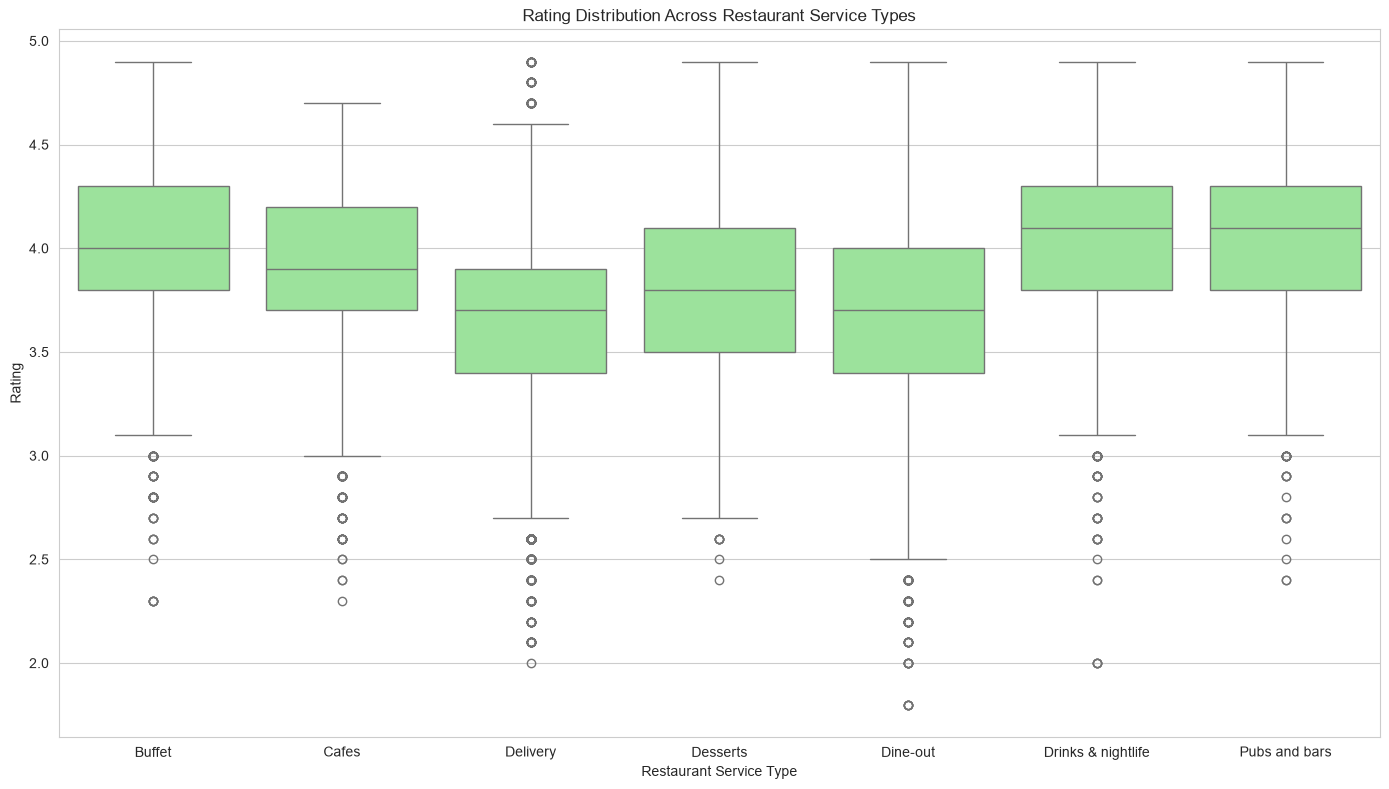

In [762]:
#How does the restaurant rating vary across different service types?

plt.figure(figsize=(14,8))
sns.boxplot(x="listed_in(type)",y="rate",data=df_cleaned,width=.8,color="lightgreen")

plt.xlabel("Restaurant Service Type")
plt.ylabel("Rating")
plt.title("Rating Distribution Across Restaurant Service Types")

plt.tight_layout()

### Key Insights

**Observation**

* Rating distributions differ across restaurant service types, with some categories exhibiting higher median ratings and greater consistency than others.

**Insight**

* Customer satisfaction varies across different restaurant service models, suggesting that service type influences the overall dining experience.

**Business Recommendation**

* Restaurant owners should identify the service models associated with consistently higher ratings and adopt best practices that enhance customer satisfaction.


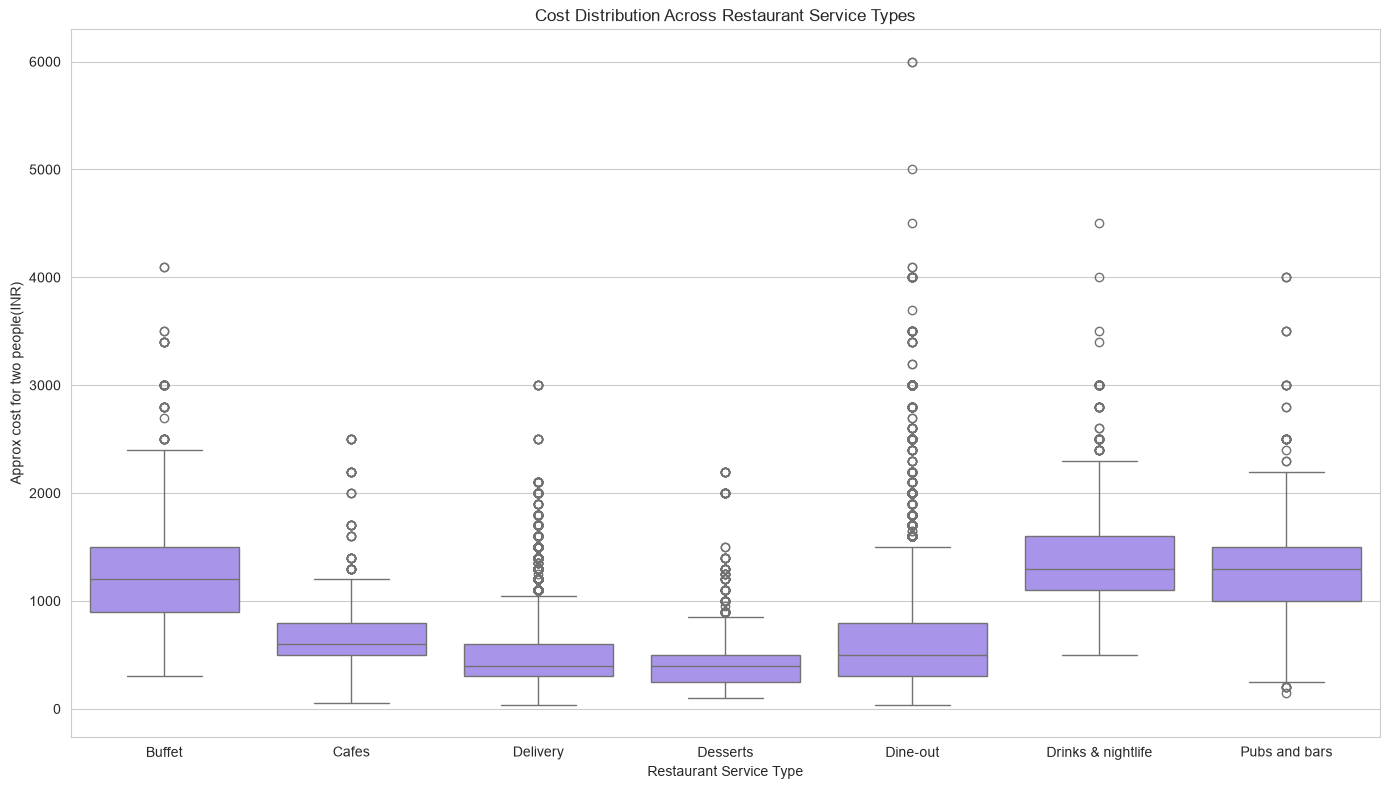

In [763]:
#Cost Distribution Across Restaurant Service Types

plt.figure(figsize=(14,8))
sns.boxplot(x="listed_in(type)",y="approx_cost(for two people)",data=df_cleaned,color="#a086f7")

plt.xlabel("Restaurant Service Type")
plt.ylabel("Approx cost for two people(INR)")
plt.title("Cost Distribution Across Restaurant Service Types")

plt.tight_layout()


### Key Insights

**Observation**

* Restaurant costs vary considerably across different service types, with certain categories generally operating at higher price ranges than others.

**Insight**

* Different restaurant service models target different customer segments based on affordability and dining preferences.

**Business Recommendation**

* Restaurants should establish pricing strategies that align with their service type and target audience while ensuring customers perceive good value for money.


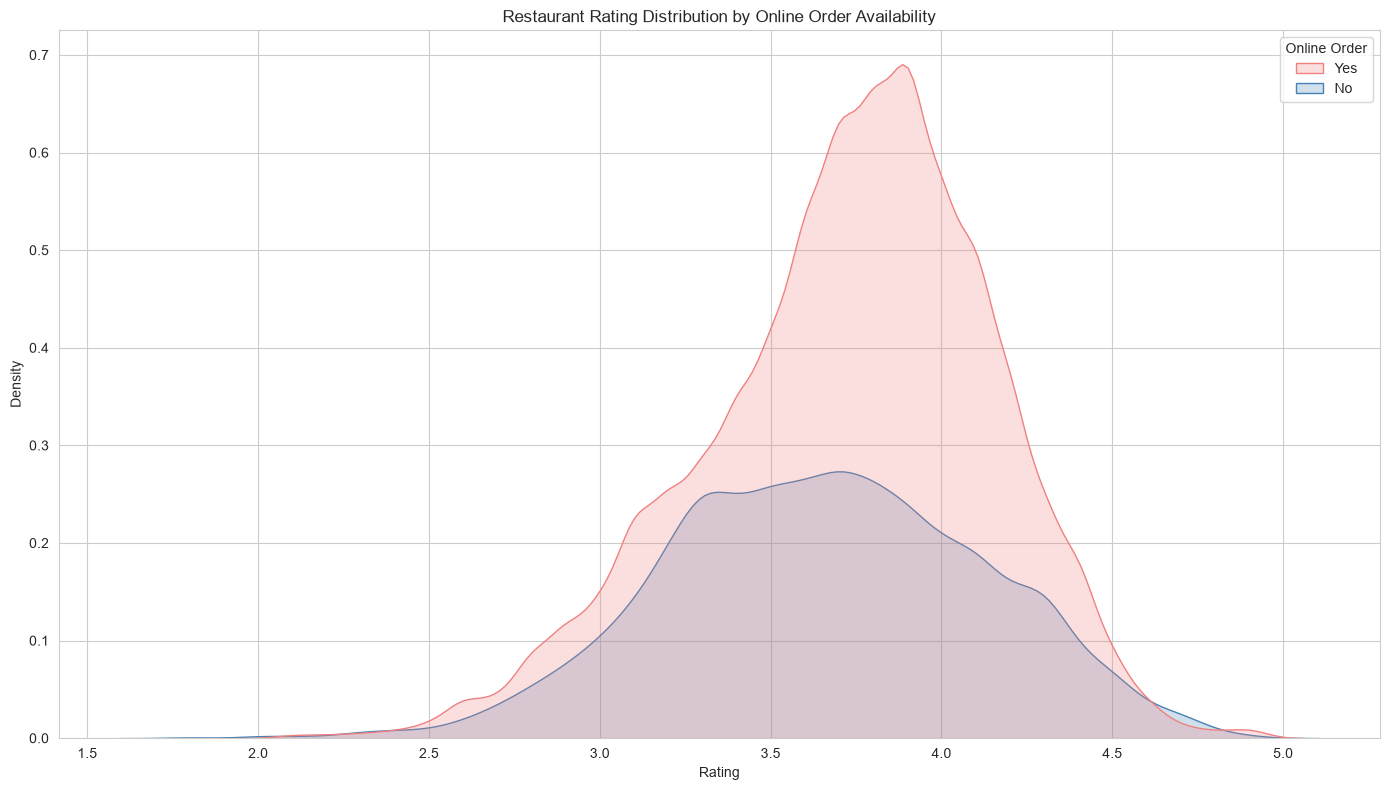

In [764]:
#Rating by service type

comparison_online=df_cleaned.copy()
comparison_online["Online Order"]=df_cleaned["online_order"]


plt.figure(figsize=(14,8))
sns.kdeplot(x="rate",hue="Online Order",data=comparison_online,fill=True,palette=["lightcoral", "steelblue"])


plt.xlabel("Rating")
plt.ylabel("Density")
plt.title("Restaurant Rating Distribution by Online Order Availability")



plt.tight_layout()


### Key Insights

**Observation**

* The rating distributions of restaurants offering online ordering and those without online ordering are broadly similar, with slight differences in their density across rating ranges.

**Insight**

* Providing online ordering alone does not guarantee higher customer ratings, indicating that other factors such as food quality and service remain equally important.

**Business Recommendation**

* Restaurants should treat online ordering as an additional customer convenience while continuing to prioritize food quality, timely service, and overall customer experience.


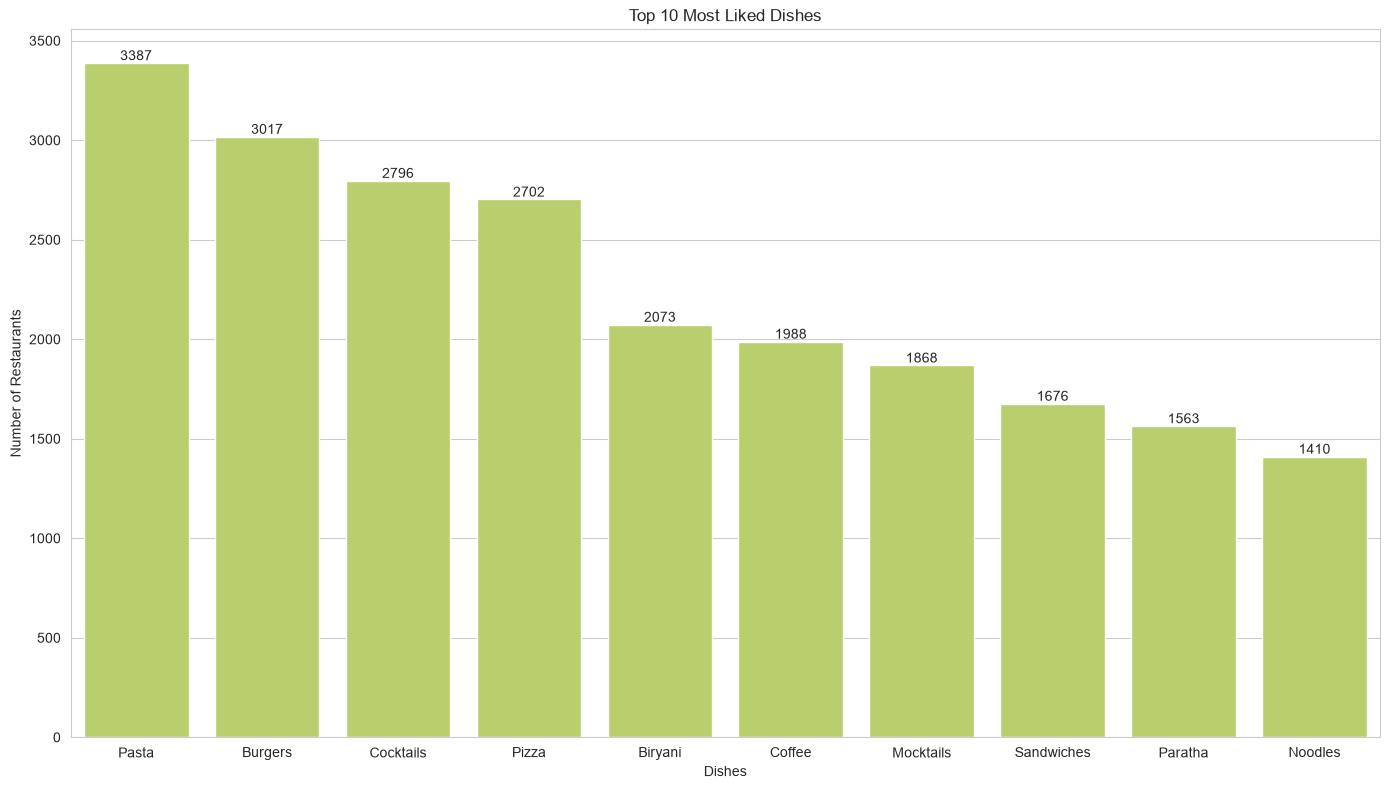

In [765]:
#Top 10 most Liked Dishes


comparison_liked=df_dish["dish_liked"].value_counts().head(10).reset_index(name="count")


plt.figure(figsize=(14,8))
ax=sns.barplot(x="dish_liked",y="count",data=comparison_liked,color="#c2de5c")

for i in ax.containers:
    ax.bar_label(i)

plt.xlabel("Dishes")
plt.ylabel("Number of Restaurants")
plt.title("Top 10 Most Liked Dishes")

plt.tight_layout()


### Key Insights

**Observation**

* A few dishes like Pasta and Burgers consistently appear among the most liked menu items across restaurants, indicating strong customer preference for these dishes.

**Insight**

* Popular dishes have broad customer acceptance and can significantly contribute to attracting and retaining customers.

**Business Recommendation**

* Restaurants should include popular dishes in their menu while also maintaining quality and introducing unique signature dishes to differentiate themselves from competitors.


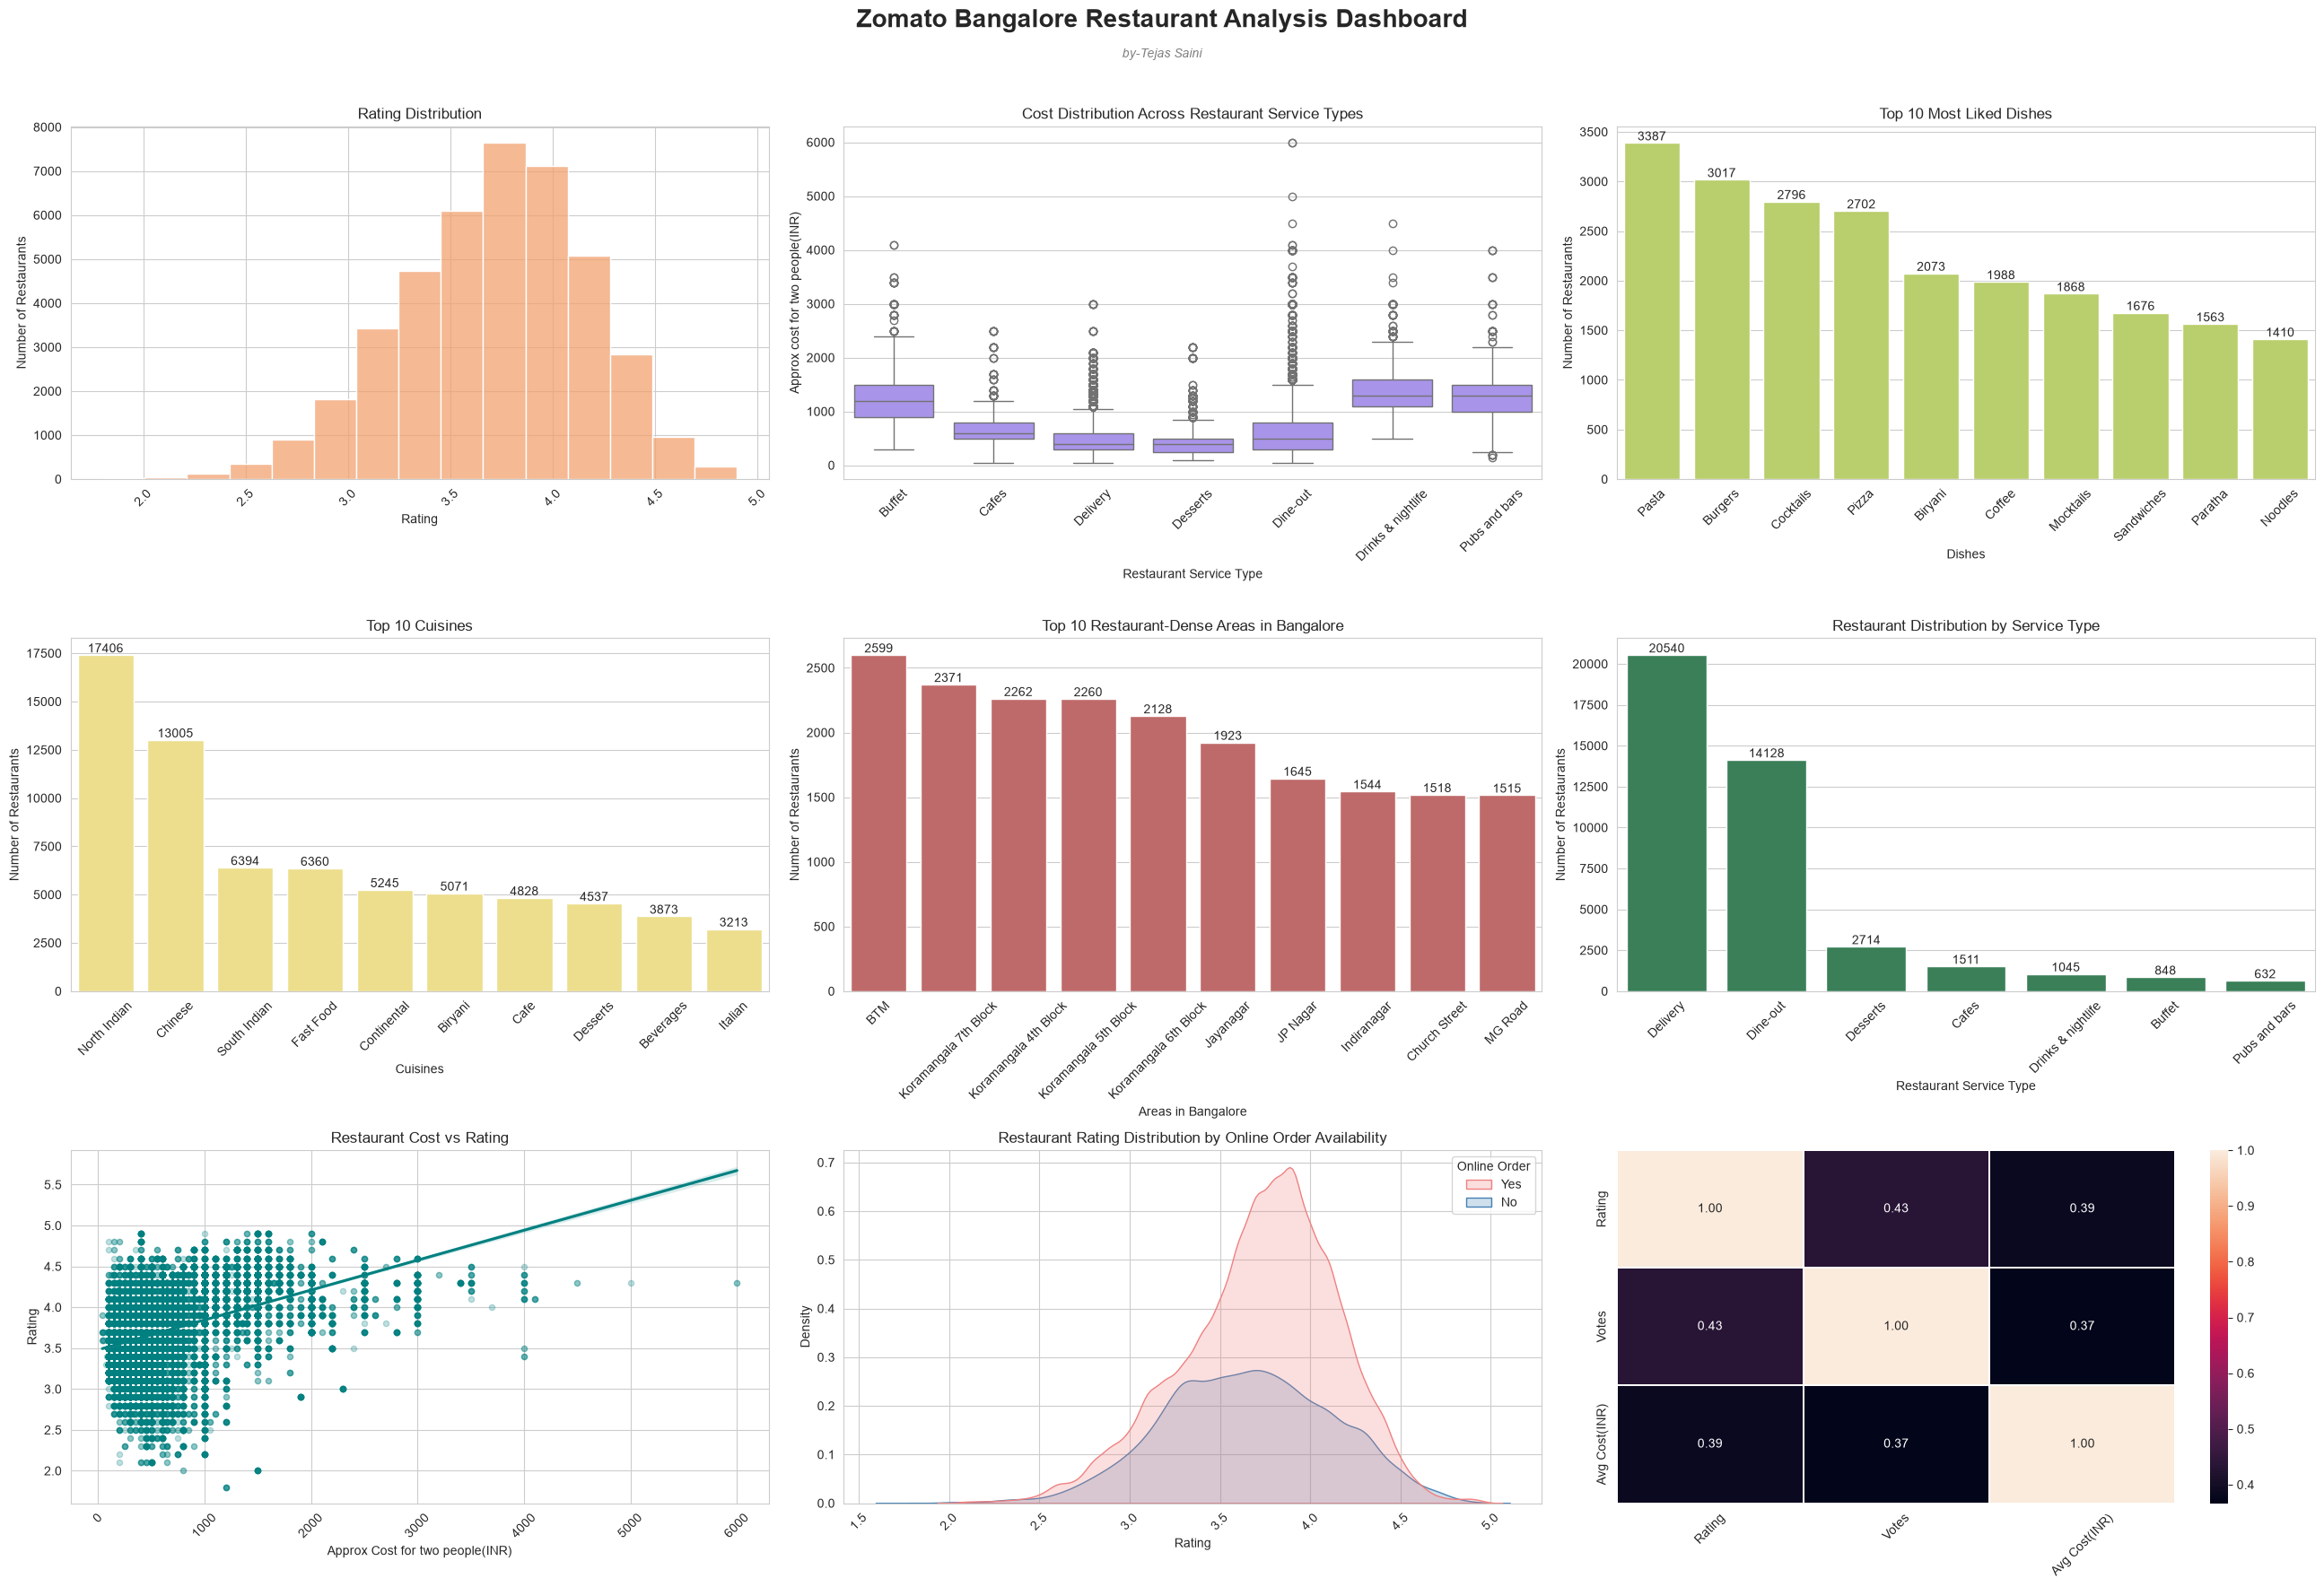

In [766]:
#Dashboard

fig,axes=plt.subplots(3,3,figsize=(26,18))

fig.suptitle("Zomato Bangalore Restaurant Analysis Dashboard",fontsize=20,fontweight="bold")
fig.text(
    0.5, 0.95,
    "by-Tejas Saini",
    ha="center",
    fontsize=10,
    color="gray", fontstyle="italic"
)

plt.subplots_adjust(hspace=.6,wspace=.35)


#Row 1:  #f2a270

sns.histplot(data=df_cleaned["rate"],bins=15,color="#f2a270",ax=axes[0,0])
axes[0,0].set_title("Rating Distribution")
axes[0,0].set_xlabel("Rating")
axes[0,0].set_ylabel("Number of Restaurants")


sns.boxplot(x="listed_in(type)",y="approx_cost(for two people)",data=df_cleaned,color="#a086f7",ax=axes[0,1])
axes[0,1].set_title("Cost Distribution Across Restaurant Service Types")
axes[0,1].tick_params(axis="x",rotation=90)
axes[0,1].set_xlabel("Restaurant Service Type")
axes[0,1].set_ylabel("Approx cost for two people(INR)")


sns.barplot(x="dish_liked",y="count",data=comparison_liked,color="#c2de5c",ax=axes[0,2])
axes[0,2].set_title("Top 10 Most Liked Dishes")
axes[0,2].tick_params(axis="x",rotation=90)
axes[0,2].set_xlabel("Dishes")
axes[0,2].set_ylabel("Number of Restaurants")

for i in axes[0,2].containers:
      axes[0,2].bar_label(i)


#Row 2:

sns.barplot(x="cuisines",y="count",data=comparison_cuisines,color="#FCE97C",ax=axes[1,0])
axes[1,0].set_title("Top 10 Cuisines")
axes[1,0].tick_params(axis="x",rotation=90)
axes[1,0].set_xlabel("Cuisines")
axes[1,0].set_ylabel("Number of Restaurants")

for i in axes[1,0].containers:
       axes[1,0].bar_label(i)



sns.barplot(x="listed_in(city)",y="count",data=comparison_location,color="indianred",ax=axes[1,1])
axes[1,1].set_title("Top 10 Restaurant-Dense Areas in Bangalore")
axes[1,1].tick_params(axis="x",rotation=90)
axes[1,1].set_xlabel("Areas in Bangalore")
axes[1,1].set_ylabel("Number of Restaurants")

for i in axes[1,1].containers:
       axes[1,1].bar_label(i)


sns.barplot(x="listed_in(type)",y="count",data=comparison_type,color="seagreen",ax=axes[1,2])
axes[1,2].set_title("Restaurant Distribution by Service Type")
axes[1,2].tick_params(axis="x",rotation=90)
axes[1,2].set_xlabel("Restaurant Service Type")
axes[1,2].set_ylabel("Number of Restaurants")

for i in axes[1,2].containers:
       axes[1,2].bar_label(i)

#Row 3:

sns.regplot(x="approx_cost(for two people)",y="rate",data=df_cleaned,color="teal",scatter_kws={"alpha":0.25, "s":20},ax=axes[2,0])
axes[2,0].set_title("Restaurant Cost vs Rating")
axes[2,0].set_xlabel("Approx Cost for two people(INR)")
axes[2,0].set_ylabel("Rating")


sns.kdeplot(x="rate",hue="Online Order",data=comparison_online,fill=True,palette=["lightcoral", "steelblue"],ax=axes[2,1])
axes[2,1].set_title("Restaurant Rating Distribution by Online Order Availability")
axes[2,1].set_xlabel("Rating")
axes[2,1].set_ylabel("Density")


heatmap_data=df_cleaned[["rate","votes","approx_cost(for two people)"]].copy()
heatmap_data.columns=["Rating", "Votes", "Avg Cost(INR)"]

sns.heatmap(heatmap_data.corr(),annot=True,cmap="rocket",fmt=".2f",linewidths=0.3,ax=axes[2,2])




for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45)


plt.tight_layout(rect=[0,0,1,.95])


plt.savefig(
    "zomato_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)